# PPE Detection with YOLOv8s: Frozen Backbone vs Partial Fine-Tuning

## Project overview

This notebook trains a four-class PPE object detector and compares two  strategies. The classes are Hardhat, NO-Hardhat, Safety Vest, and NO-Safety Vest.

1. Restore the dataset in Colab and inspect the pretrained YOLOv8s model.
2. Prepare training data, increase exposure to images containing NO-Safety Vest, and configure augmentation.
3. Train two independent models: freeze the entire backbone (`freeze=10`), then freeze only its first eight modules (`freeze=8`).
4. Compare the models on **validation** data, including metrics for each class. Select the model with the higher overall mAP50-95.
5. Evaluate that selected model once on the  **test** split and save its weights for a separate local webcam notebook.



## Step 1 — Install the training library

In [ ]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 618.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00


## Step 2 — Restore and check the dataset

In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount("/content/drive")

ZIP_PATH = Path("/content/drive/MyDrive/ppe_4class_v3.zip")
DATA_ROOT = Path("/content/ppe_curated_4class_v3_merged_review")

assert ZIP_PATH.exists(), "عدلي ZIP_PATH إلى مكان ملف ZIP في درايف."

if not DATA_ROOT.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_ROOT)

assert (DATA_ROOT / "data.yaml").exists(), "تأكدي من اكتمال فك الضغط."
print("Dataset ready:", DATA_ROOT)

Mounted at /content/drive
Dataset ready: /content/ppe_curated_4class_v3_merged_review


In [ ]:
import torch
import yaml
from ultralytics import YOLO

DATA_ROOT = Path("/content/ppe_curated_4class_v3_merged_review")

print("GPU available:", torch.cuda.is_available())
print("Dataset available:", DATA_ROOT.exists())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

if (DATA_ROOT / "data.yaml").exists():
    config = yaml.safe_load((DATA_ROOT / "data.yaml").read_text())
    print("Classes:", config["names"])

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU available: True
Dataset available: True
GPU: Tesla T4
Classes: {0: 'Hardhat', 1: 'NO-Hardhat', 2: 'Safety Vest', 3: 'NO-Safety Vest'}


## Step 3 — Inspect the pretrained model

Load `yolov8s.pt` and list its modules before choosing what to freeze.


In [ ]:
from ultralytics import YOLO

assert torch.cuda.is_available()

model = YOLO("yolov8s.pt")
BACKBONE_END = len(model.model.yaml["backbone"])

print("Backbone modules:", BACKBONE_END)
print("Index | Section | Module")

for index, layer in enumerate(model.model.model):
    section = "Backbone" if index < BACKBONE_END else "Neck / Head"
    print(f"{index:2} | {section:11} | {type(layer).__name__}")

Backbone modules: 10
Index | Section | Module
 0 | Backbone    | Conv
 1 | Backbone    | Conv
 2 | Backbone    | C2f
 3 | Backbone    | Conv
 4 | Backbone    | C2f
 5 | Backbone    | Conv
 6 | Backbone    | C2f
 7 | Backbone    | Conv
 8 | Backbone    | C2f
 9 | Backbone    | SPPF
10 | Neck / Head | Upsample
11 | Neck / Head | Concat
12 | Neck / Head | C2f
13 | Neck / Head | Upsample
14 | Neck / Head | Concat
15 | Neck / Head | C2f
16 | Neck / Head | Conv
17 | Neck / Head | Concat
18 | Neck / Head | C2f
19 | Neck / Head | Conv
20 | Neck / Head | Concat
21 | Neck / Head | C2f
22 | Neck / Head | Detect


## Step 4 — Prepare training data and augmentation

`NO-Safety Vest` was less represented in the curated data. Each **training** image containing it appears twice in a text file of image paths; other training images appear once. If a repeated image contains other classes, their boxes are seen more often too. Validation and test images remain at their original frequencies.


In [ ]:
TARGET_CLASS = 3       # NO-Safety Vest
TARGET_REPEATS = 2     # total appearances per epoch
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_paths = []
target_images = 0
original_images = 0

for image in sorted((DATA_ROOT / "train/images").iterdir()):
    if image.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    label = DATA_ROOT / "train/labels" / f"{image.stem}.txt"
    assert label.exists(), f"Missing label: {label.name}"

    classes = {
        int(line.split()[0])
        for line in label.read_text().splitlines()
        if line.strip()
    }

    contains_target = TARGET_CLASS in classes
    repeats = TARGET_REPEATS if contains_target else 1

    train_paths.extend([str(image.resolve())] * repeats)
    target_images += contains_target
    original_images += 1

assert train_paths, "No training images found."

TRAIN_LIST = Path("/content/ppe_train_oversampled.txt")
TRAIN_LIST.write_text("\n".join(train_paths) + "\n")

# Write a new YAML without changing the original dataset file
config = yaml.safe_load((DATA_ROOT / "data.yaml").read_text())
config.update(
    path=str(DATA_ROOT),
    train=str(TRAIN_LIST),
    val=str(DATA_ROOT / "valid/images"),
    test=str(DATA_ROOT / "test/images"),
)

DATA_YAML = Path("/content/ppe_training_data.yaml")
DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False))

# Shared settings for both strategies
COMMON_SETTINGS = dict(
    data=str(DATA_YAML),
    epochs=20,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    seed=42,
    device=0,
    workers=2,
    plots=True,
    project="/content/drive/MyDrive/ppe_experiments",

    # Augmentation
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.2,
    hsv_v=0.2,


)

print("Original training images:", original_images)
print("Images containing NO-Safety Vest:", target_images)
print("Training entries per epoch:", len(train_paths))

Original training images: 3403
Images containing NO-Safety Vest: 661
Training entries per epoch: 4064


## Step 5 — Strategy 1: frozen backbone

`freeze=10` freezes backbone modules 0–9; the neck and detection head learn the four PPE classes and bounding boxes. Starting from `yolov8s.pt`, the model trains for 20 epochs using the shared settings. `RUN_1` records its output directory, including `results.csv` and `weights/best.pt`.


In [ ]:
from ultralytics import YOLO

strategy_1 = YOLO("yolov8s.pt")

strategy_1.train(
    **COMMON_SETTINGS,
    freeze=10,
    name="strategy_1_backbone_frozen",
)

RUN_1 = Path(strategy_1.trainer.save_dir)
print("Results saved to:", RUN_1)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_training_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=strategy_1_backbone_frozen, nbs=64, nms=None, opset=None, 

## Step 6 — Plot strategy 1



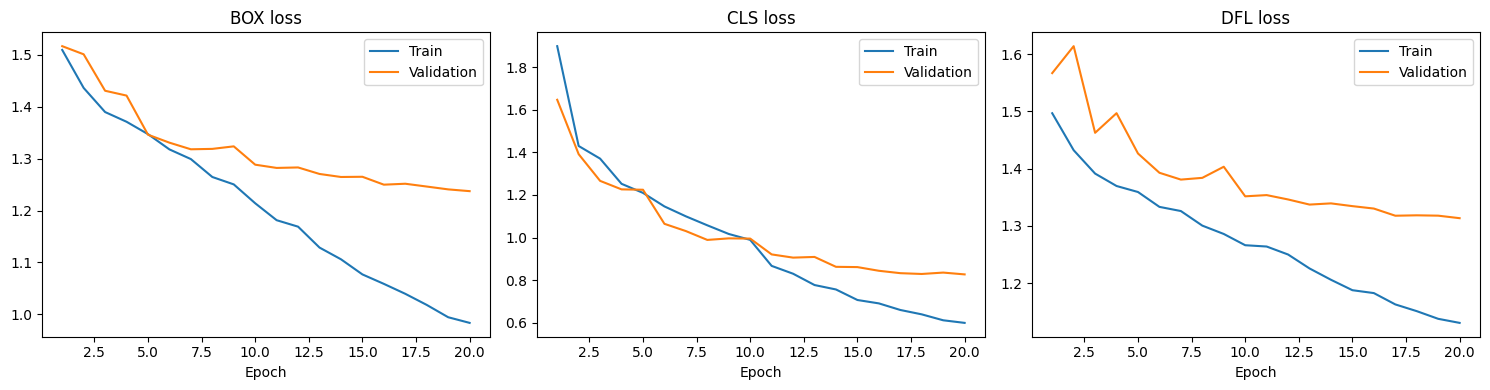

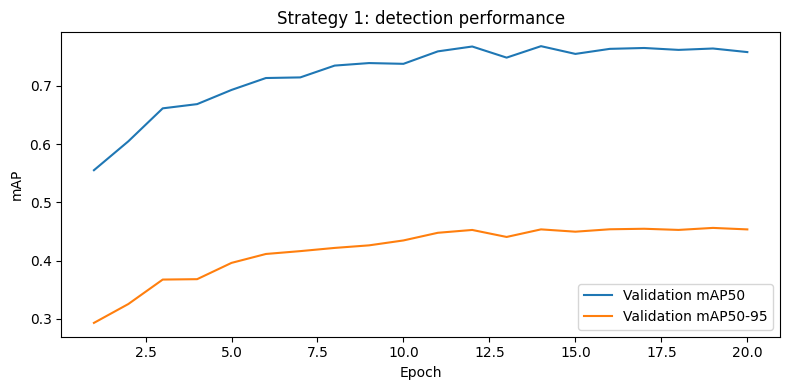

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history_1 = pd.read_csv(RUN_1 / "results.csv")
history_1.columns = history_1.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, component in zip(axes, ["box", "cls", "dfl"]):
    ax.plot(history_1["epoch"], history_1[f"train/{component}_loss"],
            label="Train")
    ax.plot(history_1["epoch"], history_1[f"val/{component}_loss"],
            label="Validation")
    ax.set_title(f"{component.upper()} loss")
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_1["epoch"], history_1["metrics/mAP50(B)"],
         label="Validation mAP50")
plt.plot(history_1["epoch"], history_1["metrics/mAP50-95(B)"],
         label="Validation mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Strategy 1: detection performance")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 — Strategy 2: partial fine-tuning

Start a **new** YOLOv8s model from the same pretrained weights. `freeze=8` keeps backbone modules 0–7 frozen and trains modules 8–9 plus the neck and detection head. This lets later image features adapt to PPE while early features remain fixed. Use the same settings, including repeated training paths and augmentation, for a meaningful comparison. `RUN_2` stores this run's checkpoints and history.


In [ ]:
strategy_2 = YOLO("yolov8s.pt")

strategy_2.train(
    **COMMON_SETTINGS,
    freeze=8,
    name="strategy_2_partial_finetuning",
)

RUN_2 = Path(strategy_2.trainer.save_dir)
print("Results saved to:", RUN_2)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_training_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=8, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=strategy_2_partial_finetuning, nbs=64, nms=None, opset=None

## Step 8 — Plot strategy 2




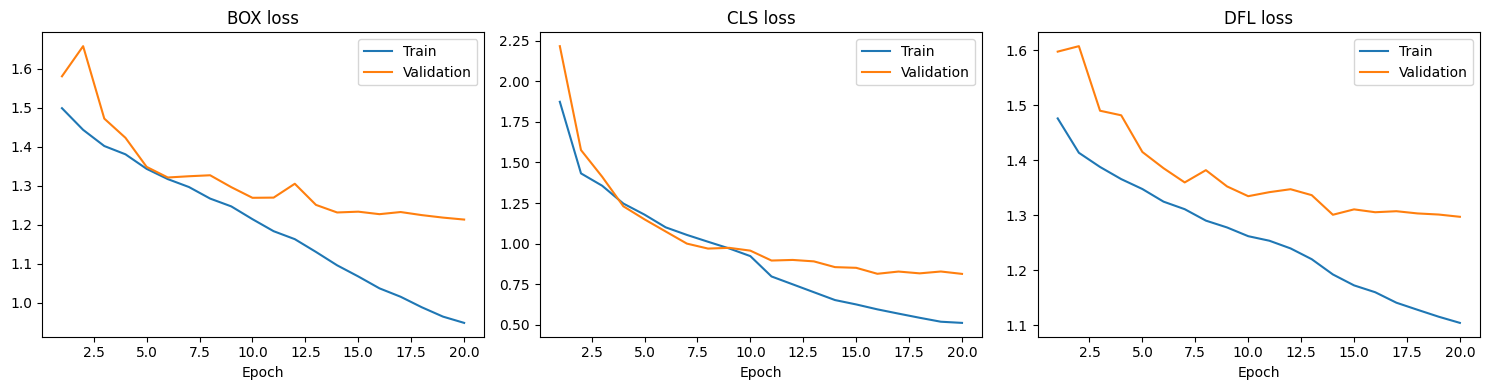

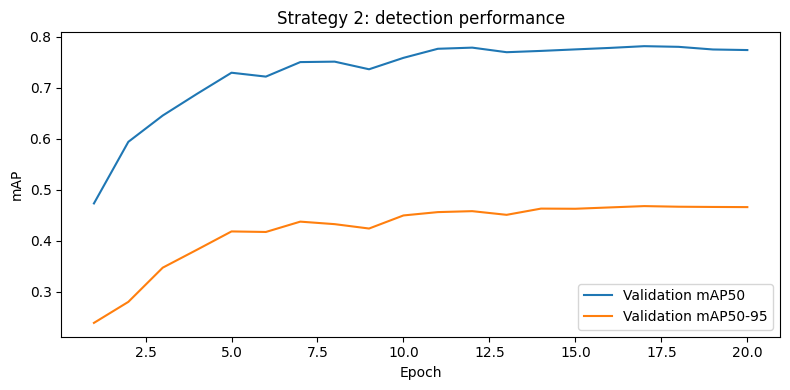

In [ ]:
history_2 = pd.read_csv(RUN_2 / "results.csv")
history_2.columns = history_2.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, component in zip(axes, ["box", "cls", "dfl"]):
    ax.plot(history_2["epoch"], history_2[f"train/{component}_loss"], label="Train")
    ax.plot(history_2["epoch"], history_2[f"val/{component}_loss"], label="Validation")
    ax.set_title(f"{component.upper()} loss")
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_2["epoch"], history_2["metrics/mAP50(B)"], label="Validation mAP50")
plt.plot(history_2["epoch"], history_2["metrics/mAP50-95(B)"], label="Validation mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Strategy 2: detection performance")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Compare both models on validation data

Load each run's **best** checkpoint and evaluate it on the same 993 validation images. The first table reports overall precision, recall, F1, mAP50, and mAP50-95; the second reports these metrics per class. `BEST_NAME` selects the higher overall mAP50-95, while the NO-Safety Vest row shows the safety-relevant precision/recall tradeoff.


In [ ]:
runs = {
    "Frozen backbone": RUN_1,
    "Partial fine-tuning": RUN_2,
}

summary_rows = []
class_rows = []

for strategy_name, run_path in runs.items():
    model = YOLO(str(run_path / "weights" / "best.pt"))

    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=640,
        batch=16,
        device=0,
        workers=2,
        plots=False,
    )

    summary_rows.append({
        "Strategy": strategy_name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "F1": metrics.box.f1.mean(),
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
    })

    for i, class_id in enumerate(metrics.box.ap_class_index):
        precision, recall, ap50, ap = metrics.box.class_result(i)

        class_rows.append({
            "Strategy": strategy_name,
            "Class": metrics.names[int(class_id)],
            "Precision": precision,
            "Recall": recall,
            "F1": metrics.box.f1[i],
            "mAP50": ap50,
            "mAP50-95": ap,
        })

comparison = pd.DataFrame(summary_rows).set_index("Strategy")
per_class = pd.DataFrame(class_rows).set_index(["Strategy", "Class"])

print("Overall validation results:")
display(comparison.round(3))

print("Validation results for each class:")
display(per_class.round(3))

BEST_NAME = comparison["mAP50-95"].idxmax()
BEST_WEIGHTS = runs[BEST_NAME] / "weights" / "best.pt"
print("Selected model:", BEST_NAME)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1718.3±514.7 MB/s, size: 51.9 KB)
val: Scanning /content/ppe_curated_4class_v3_merged_review/valid/labels.cache... 993 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 993/993 297.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.0it/s 15.6s
                   all        993       2868      0.708      0.759      0.763      0.456
               Hardhat        160        513      0.676      0.723      0.727      0.431
            NO-Hardhat        234        629      0.832      0.724      0.803      0.463
           Safety Vest        613       1302      0.833      0.866      0.907      0.613
        NO-Safety Vest        201        424      0.491      0.724      0.613      0.316
Speed: 1.1ms pre

,Precision,Recall,F1,mAP50,mAP50-95
Strategy,,,,,
Frozen backbone,0.708,0.759,0.727,0.763,0.456
Partial fine-tuning,0.753,0.758,0.752,0.782,0.468


Validation results for each class:


Precision  Recall     F1  mAP50  mAP50-95
Strategy            Class                                                    
Frozen backbone     Hardhat             0.676   0.723  0.699  0.727     0.431
                    NO-Hardhat          0.832   0.724  0.774  0.803     0.463
                    Safety Vest         0.833   0.866  0.849  0.907     0.613
                    NO-Safety Vest      0.491   0.724  0.585  0.613     0.316
Partial fine-tuning Hardhat             0.774   0.676  0.722  0.769     0.452
                    NO-Hardhat          0.838   0.772  0.803  0.821     0.476
                    Safety Vest         0.860   0.877  0.868  0.919     0.627
                    NO-Safety Vest      0.541   0.707  0.613  0.619     0.319

Selected model: Partial fine-tuning


## Step 10 — Final test and saved weights

Evaluate the selected checkpoint **once** on the 500 held-out test images. Compare the test metrics with its validation metrics and inspect the class-level results. Finally, copy the selected `best.pt` weights to `MyDrive/ppe_best.pt` for the local webcam notebook. The `val()` method evaluates predictions; it does not train the model, even when `split="test"`.


In [ ]:
import shutil

final_model = YOLO(str(BEST_WEIGHTS))

test_metrics = final_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    plots=True,
)

test_results = pd.DataFrame([{
    "Precision": test_metrics.box.mp,
    "Recall": test_metrics.box.mr,
    "F1": test_metrics.box.f1.mean(),
    "mAP50": test_metrics.box.map50,
    "mAP50-95": test_metrics.box.map,
}], index=["Test"])

print("Selected strategy:", BEST_NAME)
display(pd.concat([comparison.loc[[BEST_NAME]], test_results]).round(3))

test_class_rows = []
for i, class_id in enumerate(test_metrics.box.ap_class_index):
    precision, recall, ap50, ap = test_metrics.box.class_result(i)
    test_class_rows.append({
        "Class": test_metrics.names[int(class_id)],
        "Precision": precision,
        "Recall": recall,
        "F1": test_metrics.box.f1[i],
        "mAP50": ap50,
        "mAP50-95": ap,
    })

print("Test results for each class:")
display(pd.DataFrame(test_class_rows).set_index("Class").round(3))

EXPORT_PATH = Path("/content/drive/MyDrive/ppe_best.pt")
shutil.copy2(BEST_WEIGHTS, EXPORT_PATH)
print("Model saved to:", EXPORT_PATH)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 27.8±16.4 MB/s, size: 52.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/ppe_curated_4class_v3_merged_review/test/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 509.3it/s 1.0s
val: New cache created: /content/ppe_curated_4class_v3_merged_review/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.3it/s 9.7s
                   all        500       1478      0.758      0.741      0.768      0.449
               Hardhat         81        218      0.803      0.728      0.776      0.434
            NO-Hardhat        127        355      0.7

,Precision,Recall,F1,mAP50,mAP50-95
Partial fine-tuning,0.753,0.758,0.752,0.782,0.468
Test,0.758,0.741,0.744,0.768,0.449


Test results for each class:


,Precision,Recall,F1,mAP50,mAP50-95
Class,,,,,
Hardhat,0.803,0.728,0.763,0.776,0.434
NO-Hardhat,0.791,0.654,0.716,0.732,0.413
Safety Vest,0.862,0.834,0.848,0.908,0.610
NO-Safety Vest,0.577,0.748,0.651,0.657,0.341


Model saved to: /content/drive/MyDrive/ppe_best.pt


## Step 11 — Interpret the final results

**Why partial fine-tuning was selected.** On validation data, partial fine-tuning (`freeze=8`) achieved mAP50-95 of **0.468**, compared with **0.456** for the frozen-backbone model (`freeze=10`). Its overall precision rose from 0.708 to 0.753, F1 rose from 0.727 to 0.752, and recall was essentially unchanged (0.759 versus 0.758). Both models started from `yolov8s.pt` and used the same training data and settings.

**Rare-class tradeoff.** On validation, NO-Safety Vest precision rose from **0.491 to 0.541** and F1 from **0.585 to 0.613**; recall fell from **0.724 to 0.707**. The selected model produces fewer false alarms for this class but misses slightly more true cases under this evaluation. This tradeoff matters for a PPE use case.

**Held-out test.** The selected model achieved precision **0.758**, recall **0.741**, F1 **0.744**, mAP50 **0.768**, and mAP50-95 **0.449** on 500 test images. Its validation mAP50-95 was 0.468, a difference of 0.019. The results are reasonably close, though this test set alone does not guarantee performance at a new worksite.

**Per-class limitation.** Safety Vest had the highest test mAP50-95 (**0.610**). NO-Safety Vest remained harder (**0.341**), with precision **0.577** and recall **0.748**.


In [ ]:
from ultralytics import YOLO

onnx_path = YOLO("/content/drive/MyDrive/ppe_best.pt").export(
    format="onnx",
    imgsz=640,
)
print("ONNX model saved to:", onnx_path)